# 01 · The program is data

A gate is a promise. A pulse is the voltage an instrument emits.

You will write the first two programs of a bring-up: a readout tone with an acquisition, then a pi pulse followed by a readout. Then you take them apart. The builder hands you a tree you can inspect, transform, and save, not a string to give to a box.

Nothing here runs, on hardware or on the simulator. Part 1 builds and inspects. Part 2 presses go.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import difflib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations import Play, Wait
from qprogram.waveforms import Arbitrary, FlatTop, Gaussian, IQDrag, IQPair, Ramp, Square, SuddenNetZero

# What a core measurement can ask for, in the canonical order QProgram sorts fields into.
# A vendor extension can register more names; these three ship in the box.
print("measurement fields:", [field.value for field in MF])

measurement fields: ['state', 'iq', 'raw']


## 1.1 From a circuit to a voltage

A circuit says `X(q0)`. An instrument needs more: which output port, at what carrier frequency, with what envelope shape, for how many nanoseconds, at what amplitude. A gate carries none of that, because supplying those numbers is calibration work rather than algorithm work. QProgram keeps the program as data and lets the platform decide how to run it.

A qubit is reached by at most three coaxial lines, each with a single job. The drive line carries a tone near $f_{01}$ and rotates the state. The readout line carries a tone near $f_r$, the frequency of a resonator beside the qubit, and interrogates it. The flux line holds a near-DC level that moves $f_{01}$, on tunable qubits only. Every operation in this part puts a voltage on one of those lines or records what comes back.

### What comes back

A circuit's `measure(q0)` returns a bit. The hardware returns one complex number per shot, the amplitude and phase of a tone that went past the resonator and picked up a state-dependent shift. Turning that number into a 0 or a 1 means putting a threshold between two clouds in the IQ plane, and the threshold is a calibration of its own that Part 4 measures. Until then `MF.IQ` is the raw point and `MF.STATE` is the platform's classification of it.

Every number in the dict below was measured by a scan that has no gate-level spelling, and all of them drift. The chip here is simulated so that the scans run on a laptop.

In [3]:
# The simulated chip this tutorial calibrates. Every part uses the same numbers, and every fit you
# do later has to recover them. Part 1 needs the frequencies and the two pi amplitudes.
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit 0 transition frequency at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "q1_f01": 5.12e9,
    "q1_a_pi": 0.55,
}

print("qubit 0 drive:  ", DEVICE["q0_f01"] / 1e9, "GHz")
print("qubit 0 readout:", DEVICE["q0_fr"] / 1e9, "GHz")
print("pi amplitude:   ", DEVICE["q0_a_pi"], "(DAC units)")

qubit 0 drive:   4.85 GHz
qubit 0 readout: 7.2 GHz
pi amplitude:    0.62 (DAC units)


### Reading the datasheet

Those eleven numbers are not independent. Every experiment in this tutorial recovers one of them, and knowing what constrains what is how you tell a bad fit from a surprising result.

Start with the detuning between the qubit and its resonator.

$$\Delta = f_{01} - f_r = -2.35\ \text{GHz}$$

That gap is the whole design. Put the resonator too close and it eats the qubit's lifetime through the Purcell channel. Put it too far and it stops learning anything about the qubit's state. In between, the two systems can no longer exchange energy but they can still shift each other, and that residual shift is dispersive readout.

### The dispersive shift

$\chi$ is half the distance the resonator moves when the qubit goes from $|0\rangle$ to $|1\rangle$. For a transmon it follows from the qubit-resonator coupling $g$ and the anharmonicity $\alpha$.

$$\chi = \frac{g^2}{\Delta}\cdot\frac{\alpha}{\Delta + \alpha}$$

Put this chip's numbers in, with $\alpha \approx -300$ MHz, and it is claiming $g \approx 190$ MHz, a coupling at the top of what anybody builds. Nothing breaks here, because the simulated device was specified by the numbers you can measure rather than derived from a Hamiltonian. Do the arithmetic on a real datasheet. Parameters that do not close usually mean one of them is wrong.

### The readout ratio

The two qubit states pull the resonator apart by $2\chi$, and $\kappa$ is how wide the resonator is.

$$2\chi/\kappa = 2.4$$

Too small and the two Lorentzians overlap, and no amount of averaging separates them. Too large and the tone you park between them barely enters the cavity. Information per photon peaks near $2\chi \approx \kappa$, so this chip is a little over-separated, trading signal for cleanliness. The same linewidth fixes the cavity fill time at $1/2\pi\kappa \approx 106$ ns, and the readout pulse below is 2000 ns rather than 200 for that reason.

### The three coherence times

One hard constraint links them.

$$\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\varphi}$$

Relaxation contributes half its rate to dephasing and pure dephasing $T_\varphi$ adds the rest, so $T_1 = 18$ us puts a ceiling of 36 us on $T_2$. The measured $T_2^* = 9$ us implies 12 us of pure dephasing, and the echoed $T_2 = 16$ us implies 29 us. Refocusing removed about 60 percent of the dephasing rate, so the noise causing it is slow compared with the sequence. Part 4 measures all three and checks the inequality out loud.

### The spectroscopy linewidth

$T_2^* = 9$ us corresponds to an intrinsic line $1/\pi T_2^*$ wide, or 35 kHz, and the dict says 2 MHz. The difference is deliberate. Two-tone spectroscopy needs a saturating drive to produce any population at all, and a saturating drive broadens the line it is measuring.

$$\Delta f = \frac{1}{\pi T_2}\sqrt{1 + \Omega^2 T_1 T_2}$$

So 2 MHz corresponds to a Rabi rate of roughly 700 kHz. Part 3 drives its survey scans harder still and quotes 20 MHz on purpose, so that a coarse frequency grid cannot step over the peak.

## 1.2 Buses and schemas

A bus is one signal path taken whole, from a port on an instrument, through the attenuators and filters at each temperature stage, out at one line on the chip. QProgram names that chain once and addresses everything through the name.

The unit of addressing is the path rather than the qubit, for two reasons.

**One qubit owns several lines that have nothing in common.** `q[0].drive` is a pair of DACs feeding an IQ mixer at 4.85 GHz. `q[0].flux` is a single filtered wire holding a DC level. Different bandwidths, different waveform types, and in Part 5 different instruments in different chassis.

**One line often serves several qubits.** Readout resonators are spread across a couple of gigahertz so that one feedline and one ADC carry all of them at once. `q[0].readout` and `q[1].readout` are two frequencies on one wire.

So `play` names a bus, never a qubit. Almost every operation does, with a bare `sync()` as the exception later in this part, and the simplest spelling is a string.

In [4]:
raw = qp.QProgram(label="readout_raw_strings")
raw.set_frequency("readout_q0", DEVICE["q0_fr"])
m_raw = raw.measure("readout_q0", "readout", "weights")

print(qp.dumps(raw))
print("buses:  ", sorted(raw.buses))
print("handle: ", m_raw.name)  # a global counter: a raw string has no bus name to derive one from

#!QProgram 1.0

metadata:
  label: "readout_raw_strings"

body:
  set_frequency "readout_q0" 7200000000.0
  measure "readout_q0" "readout" "weights" name="m0"

buses:   ['readout_q0']
handle:  m0


That program is valid and it will run. Typing strings costs you two things: no tab-completion, and no checking. Misspell the bus as `"raedout_q0"` and you find out on hardware.

`BusSchema` fixes both without changing what lands in the AST. A schema declares which kinds of bus each element of the chip has. It does not declare how many qubits exist, so any index works. It hands back a `BusRef`, a real `str` subclass that also carries metadata, and everywhere QProgram wants a bus name a `BusRef` works.

In [5]:
schema = BusSchema.transmon()  # each qubit: drive (IQ), readout (IQ, with an ADC)
q = schema.q

readout_bus = q[0].readout
print("schema:      ", schema)
print("the ref:     ", repr(readout_bus), "| a str?", isinstance(readout_bus, str))
print("element/idx: ", readout_bus.element, readout_bus.idx)
print("kind:        ", readout_bus.kind)
print("channel:     ", readout_bus.channel, "| acquires:", readout_bus.acquires)
print("any index:   ", q[7].drive, q[7].drive.channel)

schema:       BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))
the ref:      'q0/readout' | a str? True
element/idx:  q 0
kind:         readout
channel:      IQ | acquires: True
any index:    q7/drive IQ


### What the schema catches

`channel` records how many DACs feed the line and `acquires` records whether an ADC listens to it. Both are facts about copper.

A drive line ends at an IQ mixer, which needs two synchronized DACs to place a tone at an arbitrary sideband of the local oscillator without also placing a mirror image somewhere you did not want one. So an IQ bus needs an IQ waveform, and a single-channel `Square` on one leaves half the data missing. A flux line is a single DC-coupled wire and takes one channel, with no mixer and no carrier. An ADC exists on the readout line only.

QProgram turns both facts into build-time errors:

- an IQ bus needs an IQ waveform, and a single-channel bus needs a real-valued one.
- `measure` needs a bus with an ADC.

Both raise `qp.ValidationError` on the line that made the mistake. The messages below name the bus, the reason, and what to do instead.

In [6]:
scratch = qp.QProgram(label="deliberate_mistakes", schema=schema)

try:
    scratch.play(q[0].drive, Square(amplitude=0.5, duration=40))
except qp.ValidationError as exc:
    print("channel mismatch ->", exc)

try:
    scratch.measure(q[0].drive, "readout", "weights")
except qp.ValidationError as exc:
    print("\nno ADC          ->", exc)

channel mismatch -> Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Square). Use an IQWaveform (e.g. IQPair, IQDrag) instead.

no ADC          -> Bus 'q0/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


Raw strings skip every one of these checks, on purpose. A `.qp` file can be mostly schema-backed with one odd bus slotted in by name, and QProgram will not argue. You lose the checks for that bus only.

## 1.3 Operations

Naming a line is half of the vocabulary. The other half is the list of things you can tell the electronics to do on that line, and the list is short.

| What it does | QProgram |
|---|---|
| set the modulation frequency of the pulses | `set_frequency` |
| set or zero the phase reference | `set_phase`, `reset_phase` |
| scale the whole output path | `set_gain` |
| offset the whole output path | `set_offset` |
| output one pulse envelope | `play` |
| idle a bus for a given time | `wait` |
| bring buses back to a common time reference | `sync` |
| output a pulse, integrate the return, optionally classify it | `measure` |
| repeat a block a fixed number of times | `average`, `sweep` |
| take a branch on a classified outcome | `if_` / `else_` |
| change a setting the pulse program does not own | `set_parameter` |

QProgram did not invent that vocabulary. It is roughly the intersection of what commercial sequencers offer, given portable names. Adding to it takes a vendor namespace instead of a patch to the core (Part 6), and a program written in it has a chance of running on a rack you have never seen (Part 5).

### Four hardware facts

Most of the constraints you meet later follow from these.

- **Instructions land on a clock grid**, 4 ns on a typical box. Ask for a 3 ns wait and you get 4.
- **Waveform memory is finite**, tens of thousands of samples. You play from a small library of envelopes rather than streaming samples, so a program refers to pulses and a separate library holds them (Part 3).
- **Loop counters are integer registers.** A sweep the hardware can generate on its own is one where the next value is the previous plus a constant. Everything else has to be uploaded as a table, and Part 2 is where that distinction starts costing time.
- **A branch has to resolve in tens of nanoseconds**, while the qubit is still coherent. That budget is why the conditional in Part 4 compares one classified bit against a constant and nothing wider.

### The first readout pulse

The first measurement on a new chip is the readout resonator, and the smallest useful program is one readout tone plus one acquisition. `measure` takes three arguments, the bus, the pulse to play, and the integration weights, and it outputs the pulse itself, so there is no separate `play` on the readout line.

The pulse is flat because you want the resonator in steady state for as much of the window as possible. It is long because the signal is a handful of microwave photons through an amplifier chain whose noise you cannot avoid, and signal-to-noise grows as the square root of the integration time. The other side sets the upper limit. The qubit relaxes during the measurement, so integrating for a time comparable with $T_1$ reports a state you no longer have. Two microseconds against 18 us is roughly where labs land.

`fields=` says which data you want back. `iq` is the default, and `state` asks the platform to classify the point into 0 or 1.

### The weights

The ADC hands the platform a stream of samples, and the weights multiply that stream before it is summed into the single IQ point you get back. A flat window of ones is the honest starting default, and this tutorial uses it throughout.

It is not the best you can do. The optimal weights are the difference between the average trace from $|0\rangle$ and the one from $|1\rangle$, which downweights the beginning of the record while the resonator is still filling and the two states have not separated. Labs measure that pair of traces once and keep the difference as a calibrated array, in the same library as a calibrated pi pulse.

Both pulses below are `IQPair`s because a readout line is two paths. When the quadrature is silent, `IQZero(Square(amplitude=0.2, duration=2000))` names the same pulse in one constructor, and it is the one to reach for when a calibrated single-channel envelope has to go down an IQ line.

In [7]:
readout_pulse = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
weights = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

readout_program = qp.QProgram(
    label="first_readout",
    description="One 2 us readout tone on qubit 0, integrated into one IQ point.",
    schema=schema,
)
readout_program.set_frequency(q[0].readout, DEVICE["q0_fr"])
m0 = readout_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(readout_program))

#!QProgram 1.0

metadata:
  label: "first_readout"
  description: "One 2 us readout tone on qubit 0, integrated into one IQ point."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  set_frequency q[0].readout 7200000000.0
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



### The measurement handle

`measure` returns a `MeasurementHandle`. It is how you ask for this measurement's data after the run (`result.get(m0)` in Part 2) and how you refer to its outcome inside a conditional (Part 4).

The handle is a name, nothing more. Names are auto-allocated per bus (`q0/readout/m0`, `q0/readout/m1`, and so on) unless you pass `name=`, and they are written into the `.qp` file verbatim. Handles compare by name, so a handle you reconstruct after loading a file still refers to the same measurement.

In [8]:
measure_node = readout_program.body.elements[-1]

print("handle name:  ", m0.name)
print("requested:    ", measure_node.fields)  # canonical order, not the order you asked in
print("rebuilt equal:", m0 == qp.MeasurementHandle("q0/readout/m0"))

handle name:   q0/readout/m0
requested:     ('state', 'iq')
rebuilt equal: True


### The drive sequence

Now the other half of a bring-up: put energy into the qubit, then read it. This one uses most of the verbs you will need all day.

- `set_frequency(bus, hz)` and `set_gain(bus, g)` touch hardware registers. Gain scales the whole output path; the `amplitude` inside a waveform shapes the envelope. Two different knobs.
- `reset_phase(bus)` zeroes the oscillator phase on a bus and `set_phase(bus, radians)` writes it to a value you choose. Resetting before a sequence makes every shot start from the same reference, so the phase the qubit accumulates is the phase you asked for. Setting it advances a later pulse by a chosen angle, one of the two ways a Ramsey fringe is produced and the whole of how a virtual Z gate is written.
- `play(bus, waveform)` outputs one envelope, and `wait(bus, ns)` idles one bus.
- `with program.block():` groups statements and changes nothing about what they mean. Part 2 replaces this grouping with a real sweep.

### The sync barrier

`sync(buses)` makes the listed buses agree on where "now" is. It catches people arriving from circuits, because a circuit has one global clock and a pulse program does not. Every bus keeps its **own** cursor, advanced only by the pulses and waits written to that bus, so two buses that have played different amounts have drifted apart by exactly the difference.

```text
without a sync
  q[0].drive     |play pi 40 ns|4|
  q[0].readout   |measure 2000 ns .....................................|
                 ^ both buses start from their own cursor, and both are still at 0

with sync([q[0].drive, q[0].readout])
  q[0].drive     |play pi 40 ns|4|
  q[0].readout   .................|measure 2000 ns .....................................|
                                  ^ the barrier moved the readout cursor to 44 ns
```

In the first case the acquisition runs while the qubit is still being flipped, so you measure the pulse rather than the state. The barrier holds every named bus until the furthest-ahead one has finished. `sync()` with no argument covers every bus in the program, convenient here and expensive in Part 5, and `sync([])` raises rather than guess.

A mixer does not stop the instant its envelope reaches zero, and a readout tone that starts while the drive is still ringing down measures the ringdown along with the qubit. Hence the 4 ns wait, one clock cycle on a typical sequencer.

In [9]:
pi_pulse = IQDrag(amplitude=DEVICE["q0_a_pi"], duration=40, sigma=10, beta=0.15)

drive_program = qp.QProgram(
    label="drive_then_read",
    description="A calibrated pi pulse on qubit 0, then a readout.",
    schema=schema,
)
with drive_program.block():  # the preparation, as one group
    drive_program.set_frequency(q[0].drive, DEVICE["q0_f01"])
    drive_program.set_gain(q[0].drive, 1.0)
    drive_program.reset_phase(q[0].drive)  # every shot starts from the same phase reference
    drive_program.play(q[0].drive, pi_pulse)
    drive_program.wait(q[0].drive, 4)  # ns of dead time before the readout
drive_program.sync([q[0].drive, q[0].readout])
m_drive = drive_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(drive_program))

#!QProgram 1.0

metadata:
  label: "drive_then_read"
  description: "A calibrated pi pulse on qubit 0, then a readout."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  block:
    set_frequency q[0].drive 4850000000.0
    set_gain q[0].drive 1.0
    reset_phase q[0].drive
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
    wait q[0].drive 4
  sync q[0].drive q[0].readout
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



## 1.4 Waveforms are data

Both programs above played an envelope without ever saying what an envelope is. A waveform is a pure-data description of one. It knows nothing about hardware, and it can be built, compared, and drawn with no program around it.

Three methods carry the whole contract. `envelope(resolution=1)` returns the samples as a numpy array, `get_duration()` returns nanoseconds, and `plot()` draws the envelope and hands back the matplotlib `Axes` it drew on. Reach for `plot()` whenever the goal is to look at a shape. The gallery below needs a row of six panels, so it opens the row with matplotlib and hands each panel to a waveform through `target=`. Part 4 passes the same argument to `result.plot`, to put two clouds of single shots on one axes.

### The shapes

Each of these exists because a specific thing goes wrong without it.

- **`Square`** is the readout tone, square because you want the resonator in steady state and the integration window at constant amplitude.
- **`Gaussian`** is the drive envelope, not square because a square edge is broadband. A transmon has a $|1\rangle \to |2\rangle$ transition sitting 200 to 300 MHz below the one you are aiming at, and a sharp edge puts power there. It is also the shape your AWG can actually produce.
- **`FlatTop`** is a Gaussian rise, a flat hold, and a Gaussian fall. Reach for it when the length of the interaction is the parameter you sweep and the edges have to stay bounded. Flux pulses for two-qubit gates are the usual customer.
- **`Arbitrary`** takes samples you brought yourself, from numerical optimal control or from predistortion. A flux line through a fridge is a filter with several time constants in it, so the step you asked for arrives at the chip with a tail on it. Labs measure that response once and send the inverse.

### The flux shapes

- **`Ramp`** is a linear excursion, the shape a bias line takes between two DC values.
- **`SuddenNetZero`** is the two-qubit flux pulse whose positive and negative halves cancel. Those same long time constants mean a pulse with net area leaves a residual bias behind it, so the second gate in a circuit sees a chip the first gate detuned. Zero net area, no accumulation. The `b` parameter is detuned slightly from 1 to null whatever the line adds on top.

Nothing in either waveform says it belongs on a flux line. A `Ramp` is an envelope and only that, and the line you send it down decides what it means. `BusSchema.transmon()` has no flux bus at all, and Part 3 reaches for `BusSchema.flux_tunable_transmon()` when it starts tuning the qubit with flux.

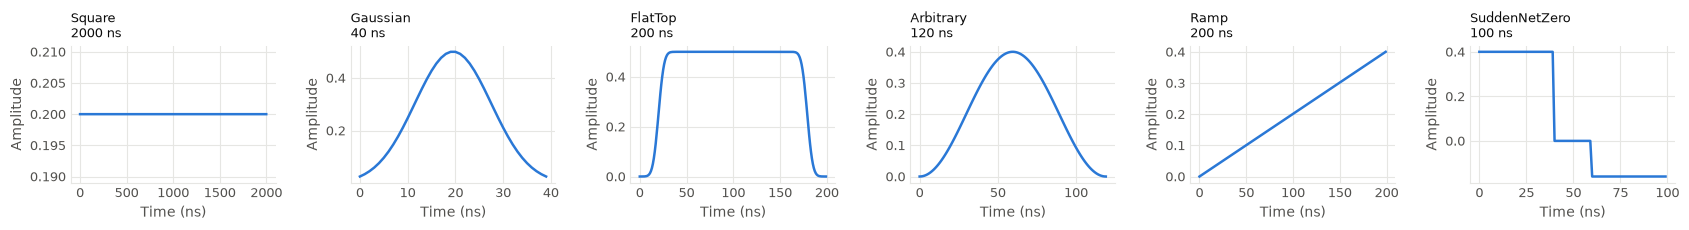

In [10]:
gallery = [
    Square(amplitude=0.2, duration=2000),  # the readout tone
    Gaussian(amplitude=0.5, duration=40, sigma=8),  # a short drive envelope
    FlatTop(amplitude=0.5, duration=200, smooth_duration=20),  # rise, hold, fall
    Arbitrary(0.4 * np.hanning(120)),  # samples you brought yourself, from optimal control or a fit
    Ramp(from_amplitude=0.0, to_amplitude=0.4, duration=200),  # a flux excursion
    SuddenNetZero(amplitude=0.4, duration=100, b=0.4, t_phi=20),  # a two-qubit gate pulse
]

fig, axes = plt.subplots(1, len(gallery), figsize=(17, 2.4))
for ax, waveform in zip(axes, gallery, strict=True):
    waveform.plot(target=ax)  # the waveform draws itself onto the panel we opened for it
    # plot() titles the panel with the class name; add the duration to it.
    ax.set_title(f"{type(waveform).__name__}\n{waveform.get_duration()} ns", loc="left", fontsize=9)
fig.tight_layout()
plt.show()

### IQ waveforms and DRAG

A drive line is a pair of paths, I and Q, fed through an IQ mixer. An `IQWaveform` carries both, and `get_I()` and `get_Q()` hand back the two halves as ordinary single-channel waveforms.

`IQDrag` is the standard drive shape, a Gaussian on I plus its scaled derivative on Q. A transmon is a ladder whose rungs are almost evenly spaced, not a two-state system that happens to have neighbours. The $|1\rangle \to |2\rangle$ transition sits only $|\alpha| \approx 300$ MHz below $|0\rangle \to |1\rangle$, so driving the lower transition at Rabi rate $\Omega$ drives the upper one too, off resonance by $\alpha$, populating $|2\rangle$ at order $(\Omega/\alpha)^2$. Most of that comes back at the end of the pulse. What stays behind is leakage out of the computational subspace, and no later correction recovers it.

### Why fast gates need it

A 40 ns pulse with `sigma=10` has a Gaussian area of roughly $\sigma\sqrt{2\pi}$, so a pi rotation needs a peak Rabi rate near 20 MHz. Against a 300 MHz anharmonicity that puts $(\Omega/\alpha)^2$ at about $4\times10^{-3}$. Shorten the same pulse to 10 ns and the peak rate goes to 80 MHz and the ratio to 7 percent, the difference between a gate you tune and a gate that does not work.

The correction is one term. A quadrature component proportional to the derivative of the envelope, $Q(t) = \beta\,\dot{I}(t)$, cancels the leading-order transfer to $|2\rangle$ and the phase error it leaves on $|1\rangle$. First order gives $\beta \approx 1/|\alpha|$, and nobody uses the first-order value. It is calibrated per qubit by a dedicated experiment.

Nothing in this tutorial measures `beta`, and the reference simulator has no third level to leak into, so the 0.15 in the cells above is a placeholder with no provenance. Treat it as you would any uncalibrated number in someone else's script.

An `IQWaveform` draws itself as two panels on a shared time axis, and `plot()` returns them as an `(I, Q)` pair, so the figure below is one call plus the labels written onto the axes that came back. The two panels carry their own vertical scales, and the difference between those scales is the physics. A derivative is antisymmetric and picks up a factor of $1/\sigma$, so with `beta=0.15` and `sigma=10` the Q peak is about a hundred times smaller than the I peak. Forced onto one axis it would be a flat line at zero.

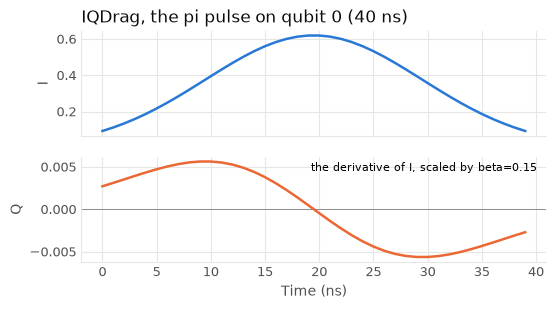

peak I: 0.6192 | peak |Q|: 0.0056


In [11]:
ax_i, ax_q = pi_pulse.plot()  # an IQWaveform hands back the two panels it drew
ax_i.set_title(f"IQDrag, the pi pulse on qubit 0 ({pi_pulse.get_duration()} ns)", loc="left")
ax_q.axhline(0.0, color="grey", linewidth=0.6)
ax_q.annotate(
    f"the derivative of I, scaled by beta={pi_pulse.beta}",
    xy=(0.98, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=8,
)
plt.show()

i_samples = pi_pulse.get_I().envelope()  # the samples themselves, for the arithmetic
q_samples = pi_pulse.get_Q().envelope()
print("peak I:", round(float(i_samples.max()), 4), "| peak |Q|:", round(float(np.abs(q_samples).max()), 4))

There is a shorter spelling still. Both waveform bases define `_repr_html_`, so a bare waveform on the last line of a notebook cell renders its own envelope with no plotting call at all, in a light and a dark version so the picture survives either notebook theme. `plot()` makes the axes the cell's value instead, which a notebook prints as `<Axes: ...>` next to the figure, so bind it or end the line with a semicolon.

In [12]:
pi_pulse

### Structural equality

Waveforms compare and hash by structure, not by identity. Two `Gaussian(0.5, 40, 8)` objects built in different cells are the same waveform. Whole-program comparison after a file round-trip depends on that, and so does the equality check in section 1.6.

In [13]:
print("same shape:      ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 8))
print("one sigma apart: ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 9))
print("the pi pulse:    ", pi_pulse == IQDrag(DEVICE["q0_a_pi"], 40, 10, 0.15))
print("distinct in a set:", len({Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 9)}))

same shape:       True
one sigma apart:  False
the pi pulse:     True
distinct in a set: 2


### String aliases

Look again at the `.qp` text of `drive_program`. The amplitude 0.62 is welded into it. That number came out of a Rabi fit and it moves as the chip drifts, so the program text changes every time the calibration changes and every diff is noise.

The worse version costs people data. A script with a literal amplitude in it claims a calibration. Run it against a chip whose pi amplitude has moved and it runs perfectly and produces numbers that mean nothing, because nothing in the file knows the number went stale.

`play` and `measure` also accept a **string alias** instead of a waveform. The program then says which pulse it wants, and the numbers arrive later from `with_waveforms`. Version the sequence, keep the amplitudes elsewhere. A program with an unbound alias cannot silently claim a stale calibration, because it does not carry one.

Part 3 fits a real pi pulse and binds it this way, and replaces the plain dict below with a `WaveformLibrary` that resolves a name differently per bus.

In [14]:
aliased = qp.QProgram(label="drive_then_read", schema=schema)
aliased.play(q[0].drive, "pi")  # whatever a pi pulse is on this chip
aliased.sync([q[0].drive, q[0].readout])
aliased.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

print(qp.dumps(aliased).split("body:")[1])  # the body only: the header holds nothing new here

calibration = {"pi": pi_pulse, "readout": readout_pulse, "weights": weights}
bound = aliased.with_waveforms(calibration)  # a new program; `aliased` is untouched
resolved = next(line.strip() for line in qp.dumps(bound).splitlines() if line.strip().startswith("play"))
print("after binding:", resolved)


  play q[0].drive "pi"
  sync q[0].drive q[0].readout
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]

after binding: play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)


## 1.5 The program is a tree

Binding a waveform produced a new program rather than mutating the old one, a hint about what a program is underneath. Every builder call appended a node. `program.body` is the root `Block`, and `body.elements` is a plain Python list of its immediate children, in the order you wrote them.

`drive_program` has three top-level children, because the four preparation statements live inside the `block()`.

In [15]:
print("top-level elements:", len(drive_program.body.elements))
for index, node in enumerate(drive_program.body.elements):
    print(f"  [{index}] {type(node).__name__:<8} buses={sorted(node.buses())}")

top-level elements: 3
  [0] Block    buses=['q0/drive']
  [1] Sync     buses=['q0/drive', 'q0/readout']
  [2] Measure  buses=['q0/readout']


`walk()` is the same tree in pre-order: the root `body` block first, then the `block()` you opened, then everything inside it, at any depth. One uniform API covers blocks and operations, so you never write the recursion yourself.

Keeping a program as data means you can compute things about a sequence before anything runs. The cell below reads how many nanoseconds this program books on the drive line, straight off the AST. Fridge time is the scarce resource in a lab, and the length of a sweep is the product of its point count, its shot count, and the length of one shot, all three sitting in the tree before you press go.

The reference simulator has no timing model, so that number comes out of your own arithmetic and nothing reports it back to you.

In [16]:
print("walk() order:")
for node in drive_program.body.walk():
    print("  ", type(node).__name__)

drive_ns = 0
for node in drive_program.body.walk():
    if isinstance(node, Play) and node.bus == q[0].drive:
        drive_ns += node.waveform.get_duration()
    elif isinstance(node, Wait) and node.bus == q[0].drive:
        drive_ns += node.duration
print("\ntime booked on q[0].drive:", drive_ns, "ns")

walk() order:
   Block
   Block
   SetFrequency
   SetGain
   ResetPhase
   Play
   Wait
   Sync
   Measure

time booked on q[0].drive: 44 ns


Four more things to know about a built program. One of them is empty on purpose.

In [17]:
print("buses:    ", sorted(drive_program.buses))
print("variables:", drive_program.variables, "<- nothing declared yet, that is Part 2")
print("waveforms:", len(drive_program.body.waveforms()), "distinct")
print("schema:   ", drive_program.schema)

buses:     ['q0/drive', 'q0/readout']
variables: [] <- nothing declared yet, that is Part 2
waveforms: 3 distinct
schema:    BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))


## 1.6 The `.qp` format

A tree of plain objects serializes. `qp.dumps` writes the `.qp` text format and `qp.loads` reads it back; `qp.save` and `qp.load` are the same pair against a file.

The format is deliberately boring. One statement per line, indentation for nesting, quoting as the type distinction, so a quoted `"readout_q0"` is a plain string and a bare `q[0].readout` is a bus path. Nothing is truncated and nothing is implied, so a program holding an `Arbitrary` of 4000 samples writes 4000 samples and a file that loads has everything the program had.

That costs something. A predistorted flux pulse becomes a large file, with no compression and no reference to an external array. The trade is a file with no dependencies: no particular numpy version, no sidecar, no database. It either parses or it does not, and there is no third outcome where it parses into something subtly different.

The round-trip is exact, and structural equality is how you check it.

In [18]:
out = Path("out")
out.mkdir(exist_ok=True)
path = out / "drive_then_read.qp"

qp.save(drive_program, path)
text = path.read_text()

reloaded = qp.load(path)
print("wrote:", path, f"({len(text.splitlines())} lines)")
print("same structure:", reloaded.body == drive_program.body)
print("same text back:", qp.dumps(reloaded) == text)

assert reloaded.body == drive_program.body  # the guarantee, spelled out
assert qp.loads(qp.dumps(drive_program)).body == drive_program.body

wrote: out/drive_then_read.qp (20 lines)
same structure: True
same text back: True


Three things follow from having that file. A text diff of two calibration runs shows exactly which numbers moved. A pulse sequence a colleague can read in a pull request gets checked before it costs fridge time. And the file is the experiment: the `.qp` next to your data still loads, still carries the measurement names you indexed the results by, and does not depend on the notebook that built it.

The first is worth doing rather than describing. `out/drive_then_read.qp` is on disk, so retune the pi pulse the way a lab would, by opening the file and changing 0.62 to 0.31 (`str.replace` stands in for the editor). The unified diff shows the one line that moved, and loading the edited text back gives a program whose body no longer compares equal to the original.

Watch the last two loops. Structural equality answers about any node in the tree, not just about a whole file, so comparing `body.elements` pairwise and then descending into the one child that changed localises a colleague's edit to a single operation without reading the file.

In [19]:
original_text = path.read_text()
edited_text = original_text.replace("amplitude=0.62", "amplitude=0.31")

diff = difflib.unified_diff(
    original_text.splitlines(keepends=True),
    edited_text.splitlines(keepends=True),
    "measured.qp",
    "retuned.qp",
)
print("".join(diff))

retuned = qp.loads(edited_text)
print("whole body equal?", retuned.body == drive_program.body)

for index, (before, after) in enumerate(zip(drive_program.body.elements, retuned.body.elements, strict=True)):
    print(f"  [{index}] {type(before).__name__:<8}", "same" if before == after else "CHANGED")

print("inside the changed block:")
inner = zip(drive_program.body.elements[0].elements, retuned.body.elements[0].elements, strict=True)
for index, (before, after) in enumerate(inner):
    print(f"  [0][{index}] {type(before).__name__:<13}", "same" if before == after else "CHANGED")

--- measured.qp
+++ retuned.qp
@@ -14,7 +14,7 @@
     set_frequency q[0].drive 4850000000.0
     set_gain q[0].drive 1.0
     reset_phase q[0].drive
-    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
+    play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.15)
     wait q[0].drive 4
   sync q[0].drive q[0].readout
   measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]

whole body equal? False
  [0] Block    CHANGED
  [1] Sync     same
  [2] Measure  same
inside the changed block:
  [0][0] SetFrequency  same
  [0][1] SetGain       same
  [0][2] ResetPhase    same
  [0][3] Play          CHANGED
  [0][4] Wait          same


### 🧩 Exercise 1.1

Build one program that excites qubit 0 and qubit 1 and reads both out, then make the schema catch a mistake.

1. One `QProgram` with `label="prepare_and_read_2q"` and the same `schema`.
2. For each qubit, `set_frequency` its drive bus to `DEVICE["q<i>_f01"]`, then `play` an `IQDrag` at `DEVICE["q<i>_a_pi"]` with `duration=40, sigma=10, beta=0.15`.
3. `program.sync()` with no arguments, so both readouts start from the same point in time.
4. `measure` both readout buses, using the `"readout"` and `"weights"` aliases and `fields=(MF.IQ, MF.STATE)`. Collect the two handles and print their names.
5. Print `qp.dumps(program)`.
6. Then, inside `try` / `except qp.ValidationError`, measure `q[1].drive` and print the message.

Look at the two handle names in the output. They tell you how per-bus numbering works.

In [20]:
two_qubit = qp.QProgram(label="prepare_and_read_2q", schema=schema)

for i in (0, 1):
    two_qubit.set_frequency(q[i].drive, DEVICE[f"q{i}_f01"])
    two_qubit.play(q[i].drive, IQDrag(amplitude=DEVICE[f"q{i}_a_pi"], duration=40, sigma=10, beta=0.15))
two_qubit.sync()  # every bus in the program, so the two readouts line up
handles = [two_qubit.measure(q[i].readout, "readout", "weights", fields=(MF.IQ, MF.STATE)) for i in (0, 1)]

print(qp.dumps(two_qubit))
print("handles:", [handle.name for handle in handles])  # per-bus counters, so both are m0

try:
    two_qubit.measure(q[1].drive, "readout", "weights")
except qp.ValidationError as exc:
    print("\ncaught:", exc)

#!QProgram 1.0

metadata:
  label: "prepare_and_read_2q"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  set_frequency q[0].drive 4850000000.0
  play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
  set_frequency q[1].drive 5120000000.0
  play q[1].drive IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.15)
  sync
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]
  measure q[1].readout "readout" "weights" name="q1/readout/m0" fields=["state", "iq"]

handles: ['q0/readout/m0', 'q1/readout/m0']



caught: Bus 'q1/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


## Recap

- A **bus** is one signal path. Strings work; a `BusSchema` gives you `BusRef`s that are still strings but carry `channel` and `acquires`. Those two fields reject a single-channel waveform on an IQ line and a `measure` on a bus with no ADC.
- **Operations** are the instrument verbs: `play`, `measure`, `wait`, `sync`, `set_frequency`, `set_gain`, `reset_phase`. You built a readout tone with an acquisition, and a pi pulse followed by a readout.
- **Waveforms are data.** `plot()` draws them, `envelope()` hands you the samples, and structural equality compares them. A string alias leaves the number to be filled in later, the seam between a stable sequence and a drifting calibration.
- **The program is a tree.** `body.elements`, `walk()`, `buses`, `variables`. You read a pulse-time budget off the AST before anything ran, the same move a compiler makes.
- **`.qp` is the artifact.** `loads(dumps(p)).body == p.body`, so a diff of two files is a diff of two calibrations.
- **The chip has a shape.** A qubit far below its resonator, a cavity the qubit state pulls apart by more than its own linewidth, a $T_1$ twice the $T_2^*$, and a spectroscopy line as wide as the drive makes it. Every scan from here on measures one of those.

## Next

Nothing you wrote said which loop runs on the sequencer and which runs on the control computer, because there were no loops. Part 2 adds them, with averaging and the results that come back.